# Projeto Fundamentos de Aprendizagem Automática

**Grupo 22**

### Membros

- **jiyi Li** (62244)
    
- **oujie Wu** (62228)
    
- **josé lourenço** (62817)
    

  

## Problema

**Estimar a nota final** com base em variáveis comportamentais:

- `student_hour`
    
- `gaming_hours`
    
- `sleep_hours`
    
- `exercise_minutes`
    
- ...
    

        

## Variáveis-Alvo (Targets)

### 1. Cenário de Regressão (y)

Estimar **Exam Score** (nota de exame). 

### 2. Cenário de Classificação (y)

Transformar a variável _Exam Score_ em categorias discretas e interpretáveis. Com base na distribuição dos dados ou em critérios pedagógicos, podemos definir:

**Classificação multiclass (Nota entre 0 até 65):**

|**Categoria**|**Intervalo (Exam Score)**|
|---|---|
|**Insuficiente**|0 a 24|
|**Suficiente**|25 a 39|
|**Bom**|40 a 65|



## Stakeholders

- Os próprios estudantes
    
- A instituição de ensino / Escola
    
- Conselheiros / Tutores
    
- Serviços de Apoio ao Estudante







### Ler ficheiro obter feature Variables e Target Variables e tratar dados missing

In [123]:
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.model_selection import KFold, train_test_split
import io
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pydot
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree



# ler ficherio de student_records com missing values
df_student_records = pd.read_csv('student_records_missing.csv')
df_colunas = df_student_records.columns

# print(df_student_records.isnull()) # imprimir df com todas as células com True/False indicando se é missing ou não

# imprimir percentagem missing values por coluna
missing_percent = df_student_records.isnull().mean() * 100 
missing_percent = missing_percent.sort_values(ascending=False) 
print("--- Taxa de missing antes do preenchimento (%) ---")
print(missing_percent[missing_percent > 0])


# Separar colunas numéricas e categóricas
num_cols = df_student_records.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df_student_records.select_dtypes(include=['object', 'string']).columns.tolist()

# print(num_cols)
# print(cat_cols)

# Preencher as colunas numéricas com a mediana
medians = df_student_records[num_cols].median()
# print("\n Medianas calculadas para colunas numéricas:")
# print(medians)
df_student_records[num_cols] = df_student_records[num_cols].fillna(medians) # fillna preenche os valores NA com a mediana calculada para cada coluna numérica

# Preencher as colunas categóricas com a moda
if len(cat_cols) > 0:
    modes = df_student_records[cat_cols].mode().iloc[0]
    df_student_records[cat_cols] = df_student_records[cat_cols].fillna(modes)

# print(df_student_records[cat_cols].mode())

print("\n Total atual de valores vazios :", df_student_records.isnull().sum().sum())
# print(df_student_records)





df_y = df_student_records['exam_score']
df_y_numerico = df_y.copy()  

# print("df_y_numerico:")
# print(df_y_numerico)




def categorizar_exame_score(score):
    if score < 25:
        return 'Insuficiente'  # Grupo em risco de reprovação
    elif 25 <= score < 40:
        return 'Suficiente'    # Grupo aprovado com nota suficiente
    else:
        return 'Bom' # Grupo excelente 

df_y_categorico = df_y.apply(categorizar_exame_score)




# OrdinalEncoder (categories=categories) para transformar as categorias em números ordinais
categories = [["Insuficiente", "Suficiente", "Bom"]]
oe = OrdinalEncoder(categories=categories)
df_y_categorico_ordinais = oe.fit_transform(df_y_categorico.to_frame())


# print("df_y_categorico:")
# print(df_y_categorico)

# print("df_y_categorico_ordinais:")
# print(df_y_categorico_ordinais)

# print(df_y_categorico.value_counts())



--- Taxa de missing antes do preenchimento (%) ---
mental_health_score    15.0
caffeine_intake_mg     10.0
screen_time_hours       8.0
social_media_hours      5.0
gender                  3.0
academic_level          2.0
dtype: float64

 Total atual de valores vazios : 0


## 2. Pipeline de Pré-processamento

### 2.1 Análise das Variáveis Categóricas — Justificação do Encoding

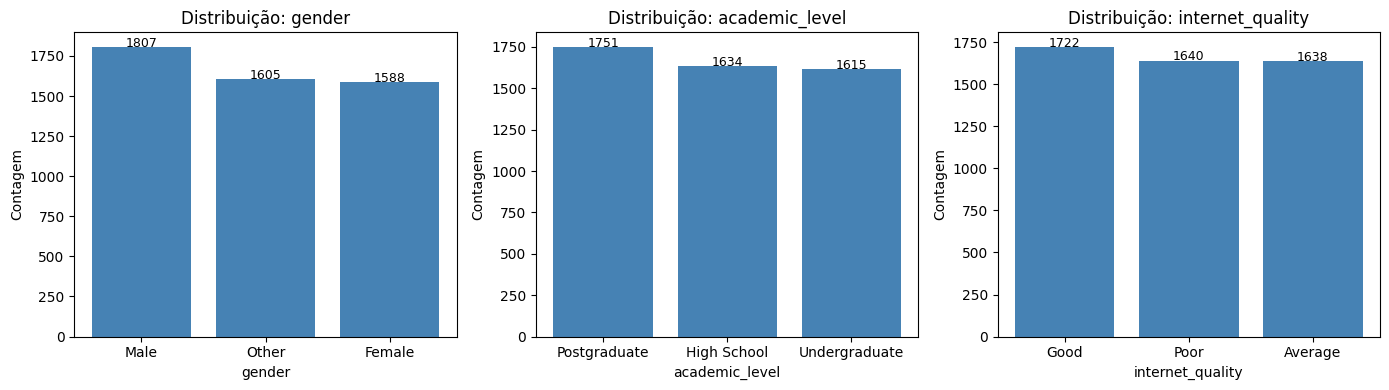

gender: ['Female', 'Male', 'Other']
academic_level: ['High School', 'Postgraduate', 'Undergraduate']
internet_quality: ['Average', 'Good', 'Poor']


In [124]:
# Análise das variáveis categóricas
categoricas = ["gender", "academic_level", "internet_quality"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(categoricas):
    counts = df_student_records[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue')
    axes[i].set_title(f'Distribuição: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Contagem')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Mostrar valores únicos de cada variável categórica
for col in categoricas:
    print(f"{col}: {sorted(df_student_records[col].unique())}")


**Justificação da escolha de One-Hot Encoding:**

-  (Male, Female, Other): variável nominal sem ordem natural entre categorias → **One-Hot Encoding**
-  (High School, Bachelor, Master): apesar de existir uma ordem implícita, a distância entre níveis não é uniforme nem quantificável → **One-Hot Encoding** para evitar que o modelo assuma relações ordinais falsas
-  (Poor, Average, Good): existe ordem natural, mas optámos por **One-Hot Encoding** para não impor uma escala numérica arbitrária (0, 1, 2) que poderia distorcer o modelo linear

### 2.2 Análise das Variáveis Numéricas — Justificação do Scaling

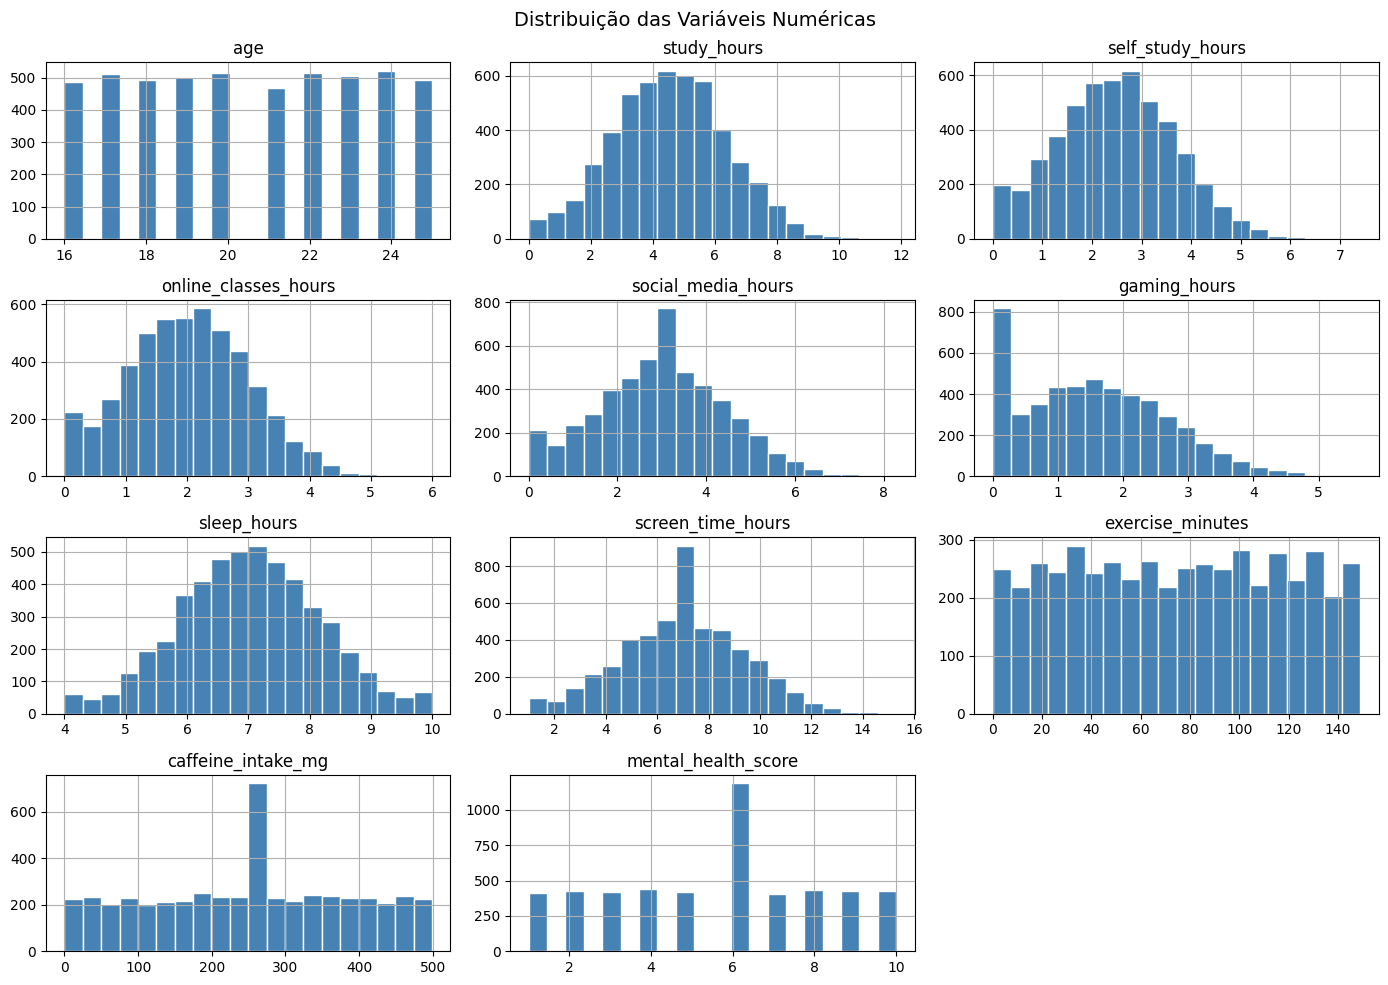

Skewness (assimetria) de cada variável numérica:
age                    -0.009
study_hours             0.057
self_study_hours        0.093
online_classes_hours    0.128
social_media_hours      0.131
gaming_hours            0.432
sleep_hours             0.007
screen_time_hours      -0.010
exercise_minutes       -0.000
caffeine_intake_mg     -0.023
mental_health_score    -0.081
dtype: float64
Regra: |skew| < 0.5 → aproximadamente normal | |skew| > 1.0 → muito assimétrica


In [125]:
numericas = ["age", "study_hours", "self_study_hours", "online_classes_hours",
             "social_media_hours", "gaming_hours", "sleep_hours",
             "screen_time_hours", "exercise_minutes", "caffeine_intake_mg",
             "mental_health_score"]

df_num = df_student_records[numericas]

# Histogramas das variáveis numéricas
df_num.hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

# Skewness (assimetria)
skewness = df_num.skew().round(3)
print("Skewness (assimetria) de cada variável numérica:")
print(skewness)
print("Regra: |skew| < 0.5 → aproximadamente normal | |skew| > 1.0 → muito assimétrica")


**Justificação da escolha de StandardScaler:**

Com base na análise de skewness acima, a maioria das variáveis numéricas apresenta assimetria baixa a moderada (|skew| < 1.0), sugerindo distribuições aproximadamente normais.

- **StandardScaler** (z = (x - μ) / σ) é adequado para distribuições aproximadamente normais, centrando os dados em 0 com desvio padrão 1
- É especialmente importante para a **Regressão Linear**, que assume que as features estão numa escala comparável
- Para a **Árvore de Decisão**, o scaling não afeta o resultado (as árvores são invariantes à escala), mas mantemos o pipeline consistente
- Variáveis como  e  têm ranges muito diferentes — sem scaling, a Regressão Linear seria dominada por essas variáveis

### Cenário de Classificação para Árvore de Decisão

In [126]:
df_student_records.drop(columns=["student_id", "exam_score","productivity_score","burnout_level","focus_index"], inplace=True)
# print(df_student_records.columns)
df_categorico = df_student_records[["gender","academic_level","internet_quality"]]
df_student_records_copy = df_student_records.copy()
# df_student_records.drop(columns=["gender", "academic_level", "internet_quality"], inplace=True)


#(One-Hot Encoding)
df_X = pd.get_dummies(df_student_records_copy, columns=df_categorico.columns.values)
# print(df_X.columns)



X = df_X.values
y = df_y_categorico_ordinais


# Utilizando three/way split
X_learning, X_test, y_learning, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7,stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_learning, y_learning, test_size=0.25, random_state=7,stratify=y_learning)

# print("Training set:", X_train.shape)
# print("Validation set:", X_val.shape)
# print("Test set:", X_test.shape)

# Treino e Avaliação de Modelos Base
param_grid = {
"criterion": ["gini", "entropy"],
"max_depth": [1, 2, 3, 4, 5, 6, None],
"min_samples_split": [2, 5, 10, 20],
"min_samples_leaf": [1, 2, 5, 10],
}

grid = GridSearchCV(
estimator=tree.DecisionTreeClassifier(random_state=7),#Semente aleatória fixa para garantir reprodutibilidade
param_grid=param_grid,#Grelha de hiperparâmetros definida acima.
scoring="accuracy",#Utilizar a acurácia como métrica de avaliação do modelo
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=7),#Validação cruzada estratificada de 5 folds, mantendo a proporção das classes em cada fold e embaralhando os dados antes da divisão.
n_jobs=-1
)

grid.fit(X_learning, y_learning) # Treinar e validar apenas no conjunto de aprendizagem

print("Best parameters:", grid.best_params_)
print("Best mean CV accuracy:", round(grid.best_score_, 3))


#utilizando bestest parameters para treinar o modelo final
final_model = grid.best_estimator_ 
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]
final_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision (macro)": precision_score(y_test, y_test_pred, average='macro'),
    "Precision (weighted)": precision_score(y_test, y_test_pred, average='weighted'),
    "Recall (macro)": recall_score(y_test, y_test_pred, average='macro'),
    "Recall (weighted)": recall_score(y_test, y_test_pred, average='weighted'),
    "F1-score (macro)": f1_score(y_test, y_test_pred, average='macro'),
    "F1-score (weighted)": f1_score(y_test, y_test_pred, average='weighted'),
})

final_metrics.round(3)






Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best mean CV accuracy: 0.757


Accuracy                0.758
Precision (macro)       0.560
Precision (weighted)    0.727
Recall (macro)          0.481
Recall (weighted)       0.758
F1-score (macro)        0.492
F1-score (weighted)     0.735
dtype: float64

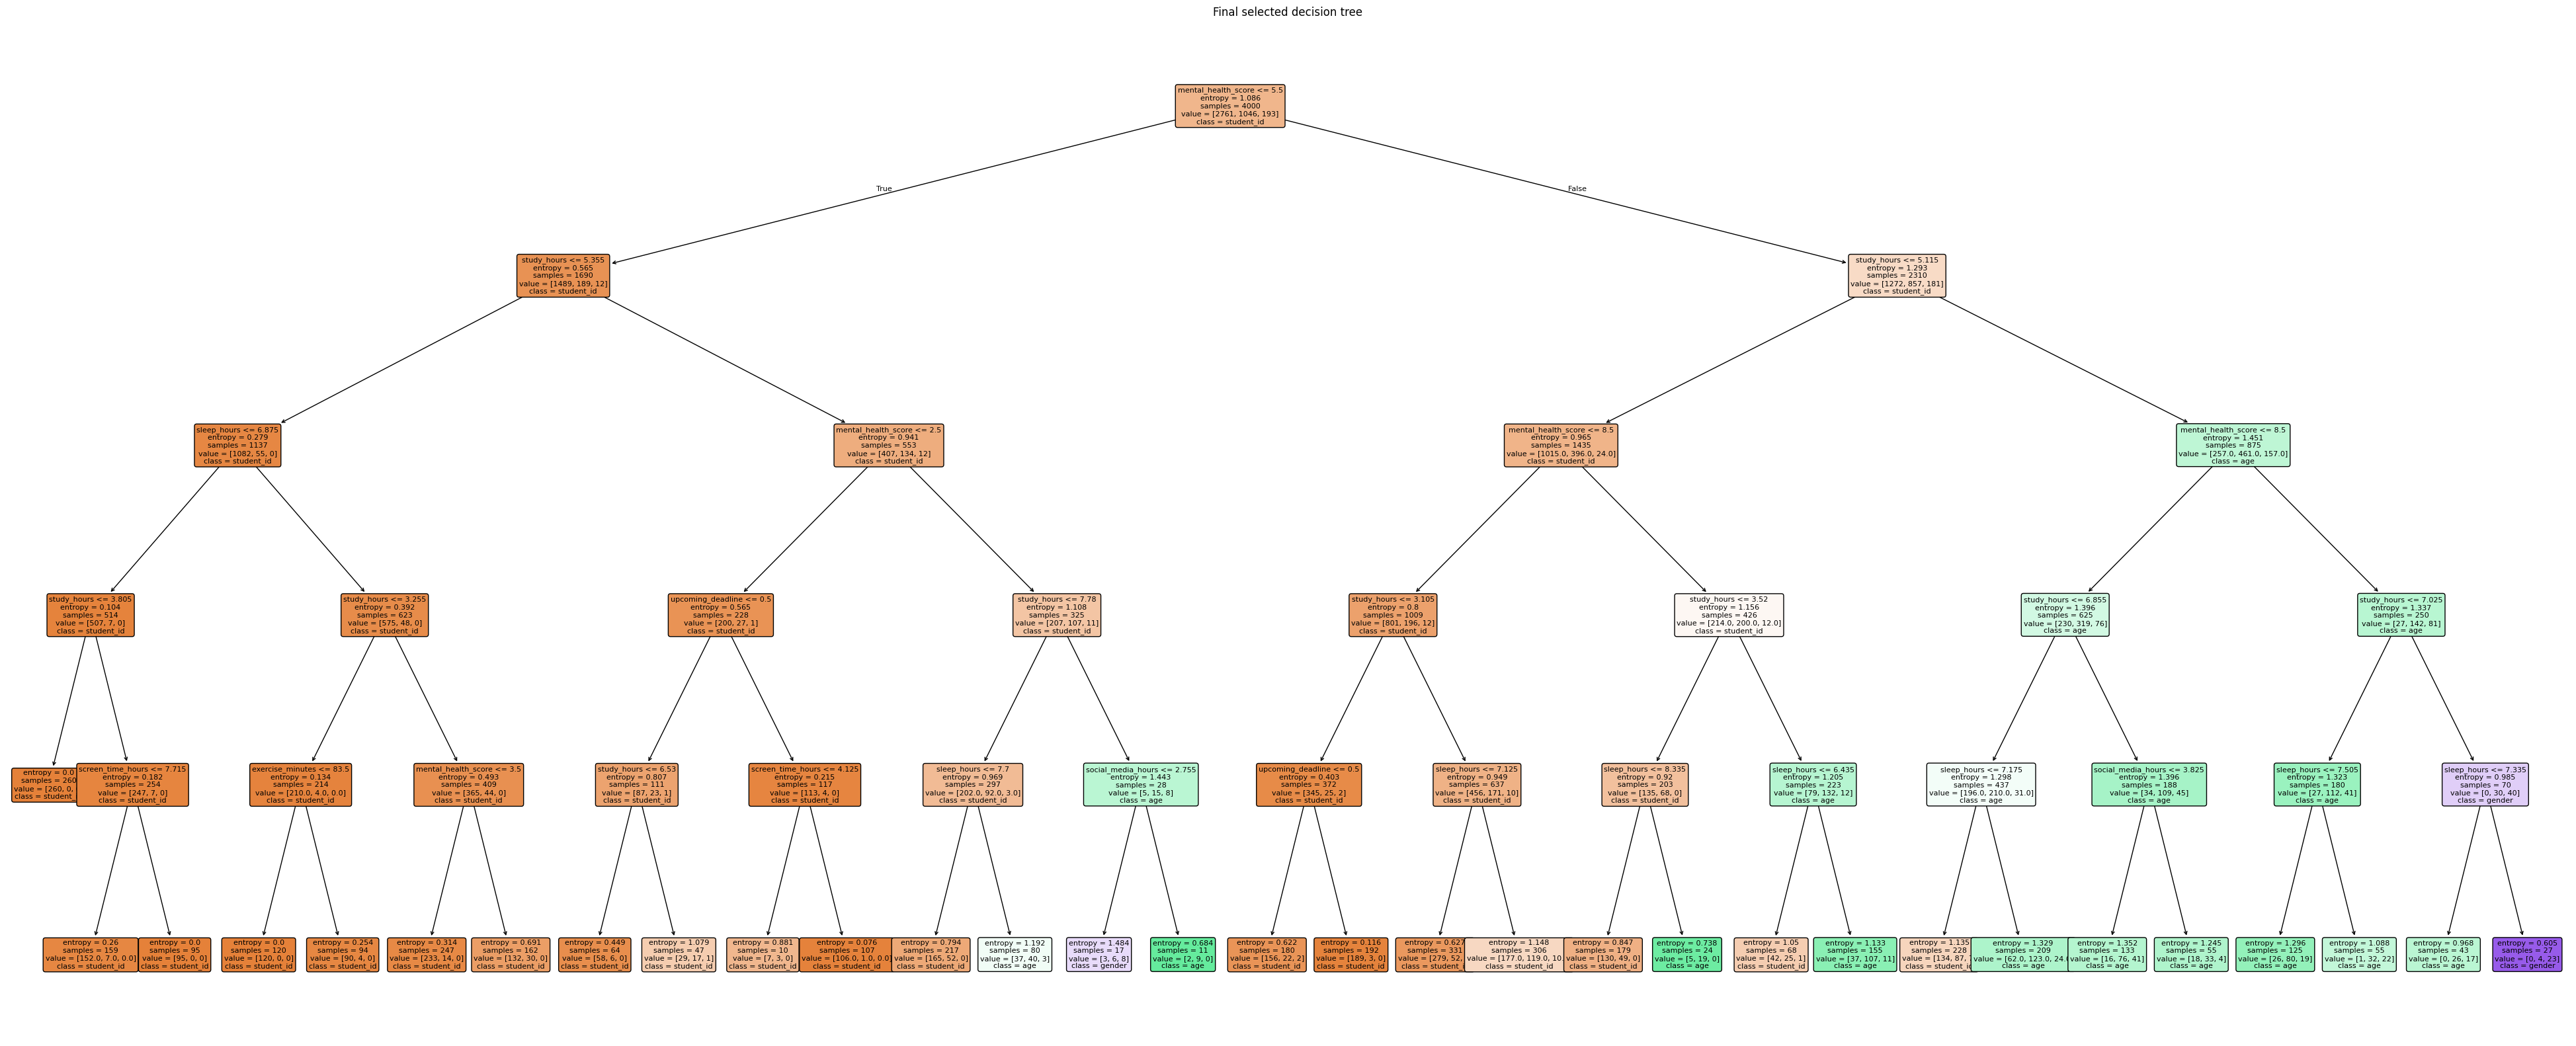

In [127]:
plt.figure(figsize=(50, 20))
plot_tree(
final_model,
feature_names=df_X.columns,
class_names=df_colunas,
filled=True,
rounded=True,
fontsize=8,
)

plt.title("Final selected decision tree")
plt.show()


### Cenário de Regressão para Árvore de Decisão

In [128]:
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y = df_y_numerico
X = df_X.values
X_learning, X_test, y_learning, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

X_train, X_val, y_train, y_val = train_test_split(
    X_learning, y_learning, test_size=0.25, random_state=7
)

param_grid = {
"criterion": ["squared_error", "absolute_error"],
"max_depth": [1, 2, 3, 4, 5, 6, None],
"min_samples_split": [2, 5, 10, 20],
"min_samples_leaf": [1, 2, 5, 10],
}

grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=7), # Utilizar árvore de regressão
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error", # Objetivo de otimização: minimizar o RMSE
    cv=KFold(n_splits=5, shuffle=True, random_state=7), # Utilizar KFold simples
    n_jobs=-1
)

grid.fit(X_learning, y_learning) # Treinar e validar no conjunto de aprendizagem

print("Best parameters:", grid.best_params_)
# O GridSearch do sklearn converte o erro em negativo, por isso é necessário negar ao extrair
print("Best mean CV RMSE:", round(-grid.best_score_, 3))

# Avaliação final no conjunto de teste
final_model = grid.best_estimator_
y_test_pred = final_model.predict(X_test)

# Calcular as métricas de avaliação específicas para regressão
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("\n--- Métricas no Conjunto de Teste (Test Set Metrics) ---")
print(f"RMSE (Root Mean Squared Error): {round(rmse, 3)}")
print(f"MAE (Mean Absolute Error): {round(mae, 3)}")
print(f"R2 Score: {round(r2, 3)}")



Best parameters: {'criterion': 'squared_error', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best mean CV RMSE: 8.379

--- Métricas no Conjunto de Teste (Test Set Metrics) ---
RMSE (Root Mean Squared Error): 8.159
MAE (Mean Absolute Error): 6.419
R2 Score: 0.553


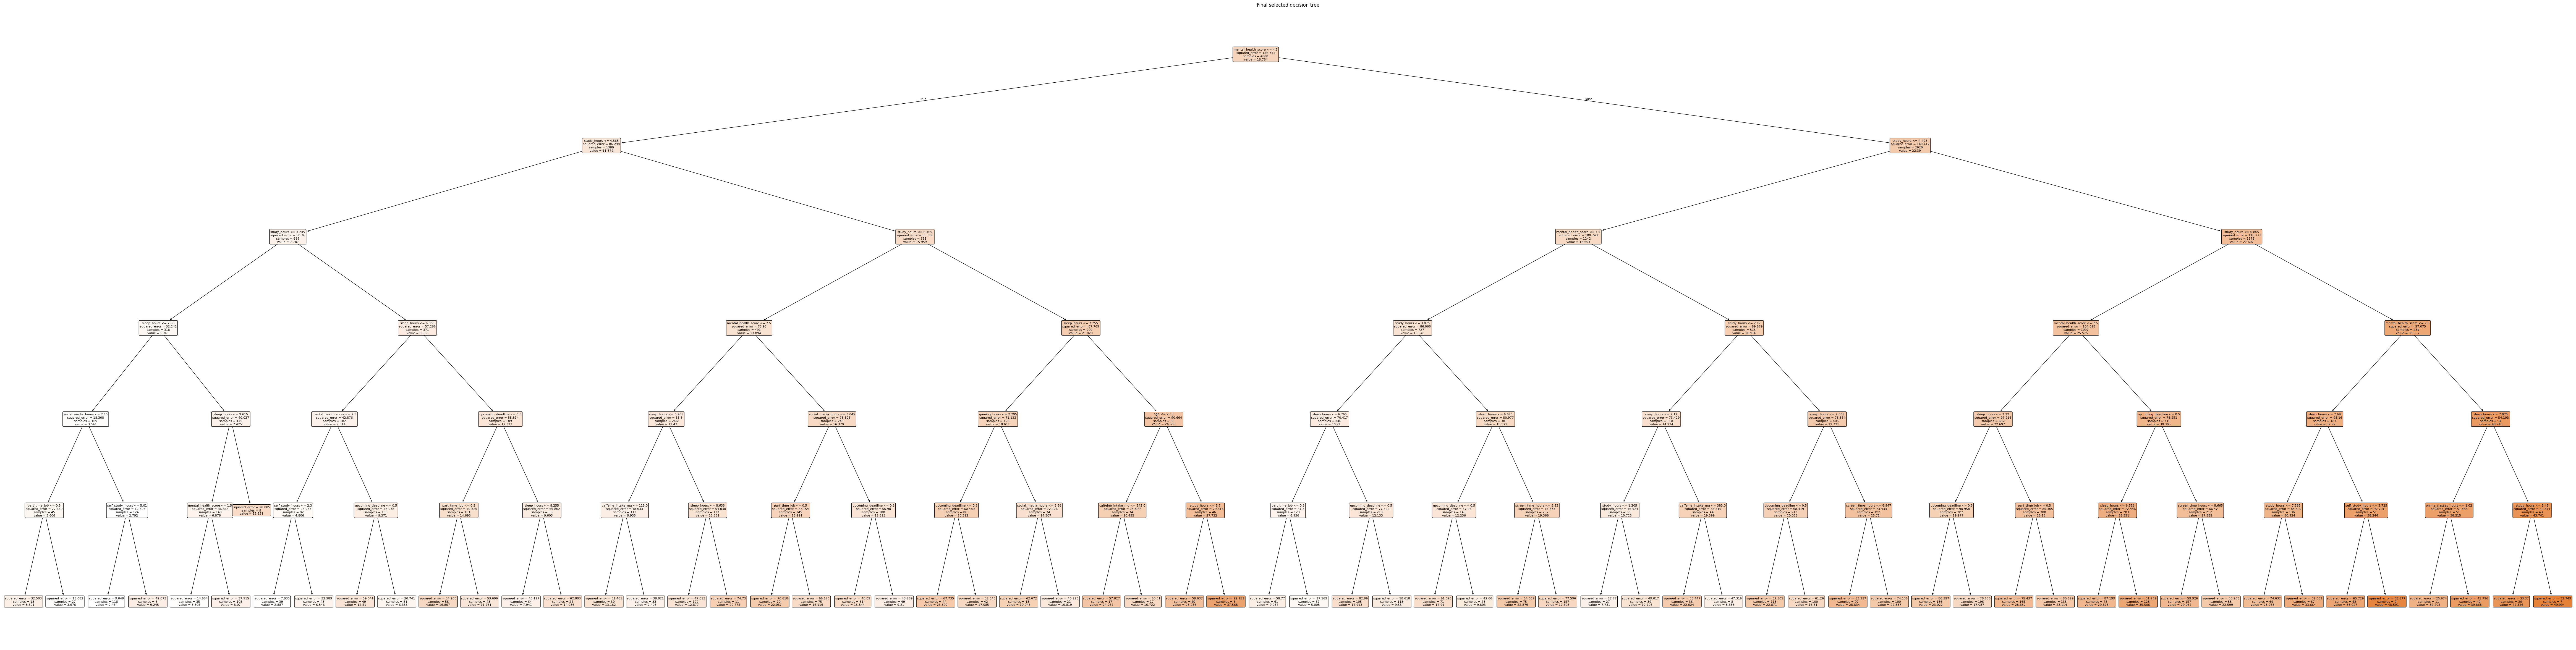

In [129]:
plt.figure(figsize=(120, 30))
plot_tree(
final_model,
feature_names=df_X.columns,
class_names=df_colunas,
filled=True,
rounded=True,
fontsize=8,
)

plt.title("Final selected decision tree")
plt.show()

### Regresao linear

The score is:  0.6846291955588342
The alpha is:  18.76843919983393
The other parameters are: 
	 B1 ->    -0.025
	 B2 ->     6.390
	 B3 ->     0.953
	 B4 ->    -0.016
	 B5 ->    -1.261
	 B6 ->    -0.667
	 B7 ->     2.957
	 B8 ->    -1.499
	 B9 ->     0.482
	 B10 ->    -0.823
	 B11 ->    -1.781
	 B12 ->    -2.475
	 B13 ->     6.178
	 B14 ->     0.089
	 B15 ->    -0.104
	 B16 ->     0.015
	 B17 ->    -0.128
	 B18 ->     0.094
	 B19 ->     0.035
	 B20 ->     0.026
	 B21 ->    -0.062
	 B22 ->     0.036
The rmse is:  6.642611797156677
The Mean Absolute Error is:  5.280231106673733
The Coefficient of Determination is:  0.7033923468596283
The Pearson Correlation Score is: 0.8388 (p-value=8.398114e-266)

The Maximum Error is:  22.697083356886424


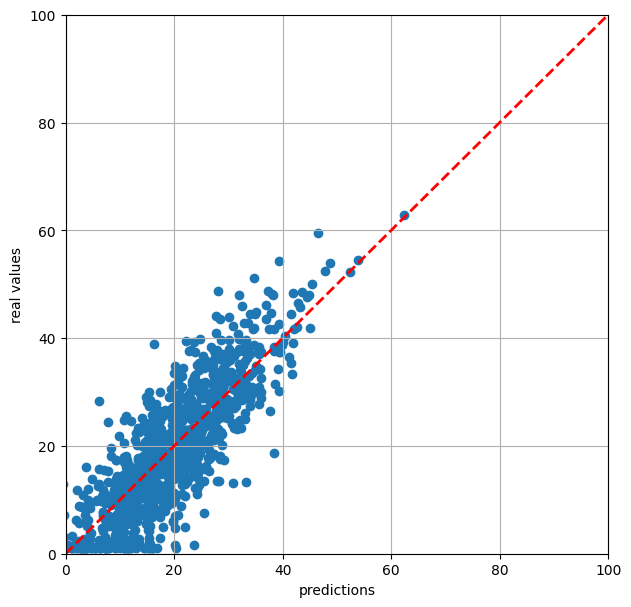

In [130]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, max_error
from scipy.stats import pearsonr

y = df_y_numerico
df_student_records_numerico = df_student_records.copy()
# print(df_student_records.columns)
df_student_records_numerico.drop(columns=["gender", "academic_level", "internet_quality"], inplace=True)
# print(df_student_records_numerico.columns)




df_xx = pd.get_dummies(df_student_records_copy, columns=df_categorico.columns.values, drop_first=True)
# print(df_X.columns)
# print(df_xx.columns)

X_train, X_test, y_train, y_test = train_test_split(
    df_X, y, test_size=0.2, random_state=7
)

# Vamos usar StandardScaler com cordo formulario: z = (x - u) / s
scaler = StandardScaler()

# Para não modificar a tabela original, criamos uma cópia para o conjunto de treino e de teste
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()


# X_train usa fit_transform, X_test só pode usar transform!
X_train_scaled[df_student_records_numerico.columns] = scaler.fit_transform(X_train[df_student_records_numerico.columns])
X_test_scaled[df_student_records_numerico.columns] = scaler.transform(X_test[df_student_records_numerico.columns])




reg = LinearRegression().fit(X_train_scaled, y_train)
print("The score is: ", reg.score(X_train_scaled, y_train))
print("The alpha is: ", reg.intercept_)
print("The other parameters are: ")
for i, beta in enumerate(reg.coef_):
    print("\t B%d -> %9.3f"% (i+1, beta))





def printRegStatistics(truth, preds):
    print("The rmse is: ", root_mean_squared_error(truth, preds)) #Quanto menor o valor, melhor o desempenho do modelo
    print("The Mean Absolute Error is: ", mean_absolute_error(truth, preds))#Quanto menor o valor, melhor o desempenho do modelo
    print("The Coefficient of Determination is: ", r2_score(truth, preds))#Quanto maior o valor (próximo de 1), melhor o desempenho do modelo
    corr, pval = pearsonr(truth, preds)
    print("The Pearson Correlation Score is: %6.4f (p-value=%e)\n"%(corr,pval))
    print("The Maximum Error is: ", max_error(truth, preds))


preds=reg.predict(X_test_scaled)
printRegStatistics(y_test, preds)
plt.figure(figsize=(7,7))
plt.scatter(preds, y_test)
plt.grid()
plt.plot([0, 100], [0, 100], c="r", linestyle='--', linewidth=2)

plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel("predictions")
plt.ylabel("real values")
plt.show()



